# Chicken vs Duck — Transfer Learning with ResNet18

Fine-tunes a pretrained ResNet18 to classify chickens vs ducks. Only the final classification head is trained; the convolutional backbone stays frozen.

**Dataset:** [roudranildas/chicken-images-classification-dataset](https://www.kaggle.com/datasets/roudranildas/chicken-images-classification-dataset/data)  
Splits (as provided): train=200, val=50, test=170.

## 1. Setup

In [16]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# keep reruns reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load the data

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("roudranildas/chicken-images-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chicken-images-classification-dataset' dataset.
Path to dataset files: /kaggle/input/chicken-images-classification-dataset


In [18]:
# ImageFolder wants <split>/<class>/, but the dataset is <class>/<split>/ — symlink to reshape
DATA_ROOT = '/root/.cache/kagglehub/datasets/roudranildas/chicken-images-classification-dataset/'
NORMALIZED_ROOT = '/content/data'

CLASSES = {'chicken': 'data/chicken-images', 'duck': 'data/duck-images'}
SPLITS = ['train', 'val', 'test']
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

data_root = Path(DATA_ROOT)
norm_root = Path(NORMALIZED_ROOT)

assert data_root.exists(), f'DATA_ROOT does not exist: {data_root}'

if norm_root.exists():
    import shutil
    shutil.rmtree(norm_root)

counts = {}
for split in SPLITS:
    for cls_name, cls_dir in CLASSES.items():
        src = data_root / cls_dir / split
        dst = norm_root / split / cls_name
        dst.mkdir(parents=True, exist_ok=True)
        if not src.exists():
            raise FileNotFoundError(f'Expected source directory not found: {src}')
        n = 0
        for img_path in sorted(src.iterdir()):
            if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
                link = dst / img_path.name
                if not link.exists():
                    os.symlink(img_path.resolve(), link)
                n += 1
        counts[(split, cls_name)] = n

print('Per-split per-class image counts:')
for split in SPLITS:
    c = counts[(split, 'chicken')]
    d = counts[(split, 'duck')]
    print(f'  {split:>5}: chicken={c:>4}  duck={d:>4}  total={c + d}')

Per-split per-class image counts:
  train: chicken= 275  duck= 622  total=897
    val: chicken=  52  duck= 109  total=161
   test: chicken= 172  duck= 310  total=482


## 3. Transforms and DataLoaders

In [19]:
# must match the stats ResNet18 was pretrained on
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# augment the training set a bit; val/test stay clean
train_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(f'{NORMALIZED_ROOT}/train', transform=train_tfms)
val_ds = datasets.ImageFolder(f'{NORMALIZED_ROOT}/val', transform=eval_tfms)
test_ds = datasets.ImageFolder(f'{NORMALIZED_ROOT}/test', transform=eval_tfms)

assert train_ds.classes == val_ds.classes == test_ds.classes, 'Class ordering mismatch between splits'
CLASS_NAMES = train_ds.classes
print(f'Classes: {CLASS_NAMES}')
print(f'Sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Classes: ['chicken', 'duck']
Sizes: train=897, val=161, test=482


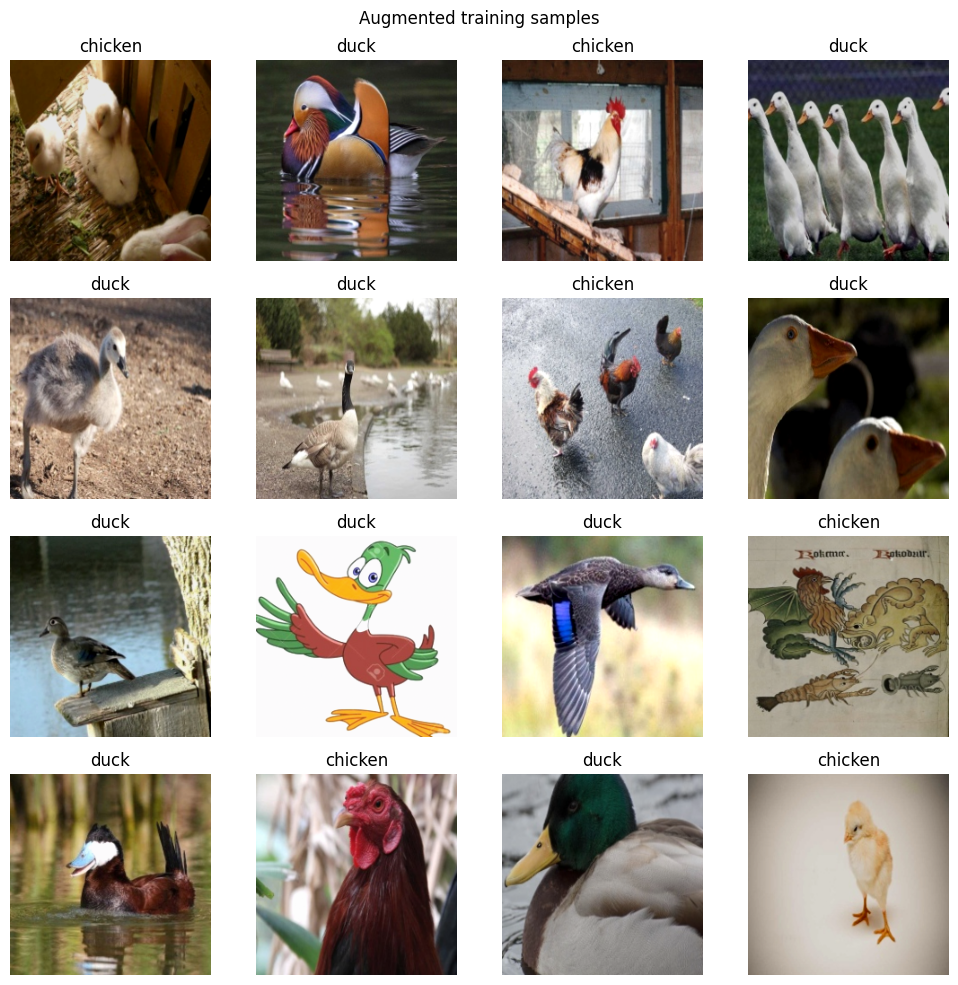

In [20]:
# quick eyeball check that labels line up with images before training
def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
n_show = min(16, len(imgs))
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
        ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis('off')
plt.suptitle('Augmented training samples')
plt.tight_layout()
plt.show()

## 4. Model — frozen ResNet18 with a new 2-class head

In [21]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# freeze the backbone — only the new head learns
for p in model.parameters():
    p.requires_grad = False

# swap the 1000-class ImageNet head for a 2-class one
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(CLASS_NAMES))
model = model.to(device)

trainable = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable parameters: {sum(p.numel() for p in trainable):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 69.0MB/s]


Trainable parameters: 1,026


## 5. Training

In [22]:
NUM_EPOCHS = 10
LR = 1e-3

criterion = nn.CrossEntropyLoss()
# backbone is frozen, so Adam only updates the head params
optimizer = optim.Adam(model.fc.parameters(), lr=LR)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
# keep the best weights, not just whatever the last epoch produced
best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())

def run_epoch(loader, training):
    model.train() if training else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7}"
print(header)
for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = run_epoch(train_loader, training=True)
    vl, va = run_epoch(val_loader, training=False)
    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)
    marker = ''
    if va > best_val_acc:
        best_val_acc = va
        best_state = copy.deepcopy(model.state_dict())
        marker = '  *best'
    print(f'{epoch:>5} | {tl:>10.4f} | {ta:>9.4f} | {vl:>8.4f} | {va:>7.4f}{marker}')

print(f'\nBest val accuracy: {best_val_acc:.4f}')

epoch | train_loss | train_acc | val_loss | val_acc
    1 |     0.3949 |    0.8395 |   0.2864 |  0.8696  *best
    2 |     0.2106 |    0.9231 |   0.2398 |  0.8944  *best
    3 |     0.1947 |    0.9287 |   0.2153 |  0.9006  *best
    4 |     0.1753 |    0.9376 |   0.2566 |  0.9006
    5 |     0.1385 |    0.9509 |   0.2181 |  0.9068  *best
    6 |     0.1614 |    0.9420 |   0.3529 |  0.8882
    7 |     0.1223 |    0.9565 |   0.2029 |  0.9130  *best
    8 |     0.1212 |    0.9576 |   0.1906 |  0.9317  *best
    9 |     0.1435 |    0.9465 |   0.2234 |  0.9130
   10 |     0.1258 |    0.9476 |   0.2135 |  0.9130

Best val accuracy: 0.9317


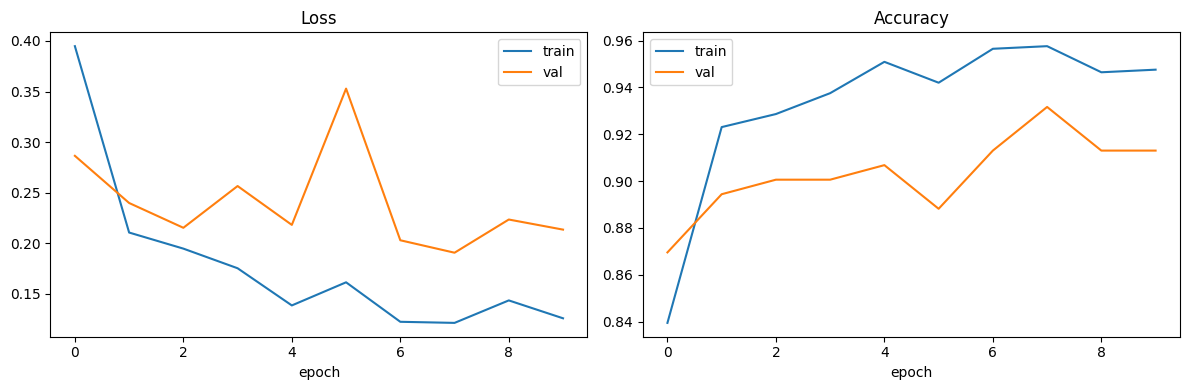

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Evaluation on the test set

The classification report on the held-out 170-image test set is the task-required output.

In [24]:
# restore the best checkpoint before scoring the test set
model.load_state_dict(best_state)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        y_true.extend(y.numpy().tolist())
        y_pred.extend(preds.tolist())

print('Classification report (test set):')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

print('Confusion matrix (rows = true, cols = predicted):')
cm = confusion_matrix(y_true, y_pred)
header_row = '          ' + '  '.join(f'{c:>8}' for c in CLASS_NAMES)
print(header_row)
for i, row in enumerate(cm):
    row_str = '  '.join(f'{v:>8}' for v in row)
    print(f'{CLASS_NAMES[i]:>8}  {row_str}')

Classification report (test set):
              precision    recall  f1-score   support

     chicken     0.9701    0.9419    0.9558       172
        duck     0.9683    0.9839    0.9760       310

    accuracy                         0.9689       482
   macro avg     0.9692    0.9629    0.9659       482
weighted avg     0.9689    0.9689    0.9688       482

Confusion matrix (rows = true, cols = predicted):
           chicken      duck
 chicken       162        10
    duck         5       305


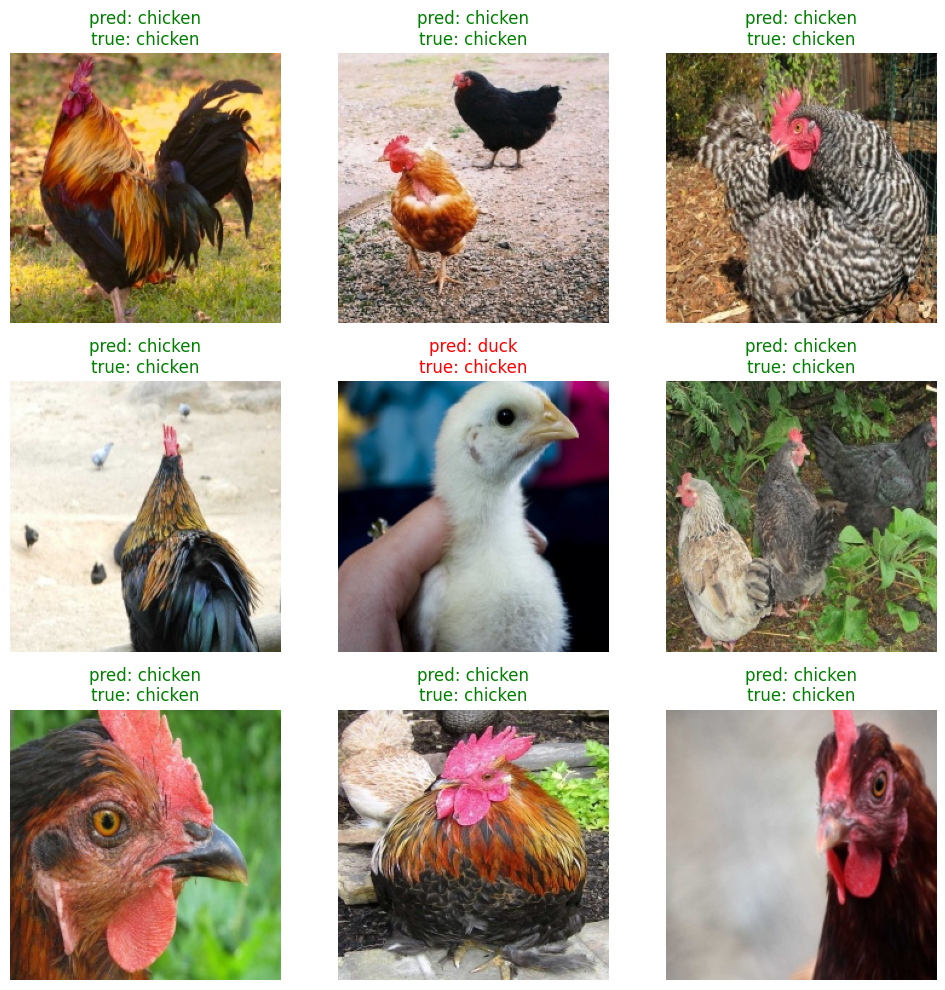

In [25]:
imgs, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(1).cpu()

n_show = min(9, len(imgs))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
        true_name = CLASS_NAMES[labels[i].item()]
        pred_name = CLASS_NAMES[preds[i].item()]
        correct = labels[i].item() == preds[i].item()
        color = 'green' if correct else 'red'  # green = right, red = wrong
        ax.set_title(f'pred: {pred_name}\ntrue: {true_name}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()